In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
pv = pd.read_csv("/kaggle/input/datasets/belovedorange/research-methodology-project/node_18_PV_actual.csv")
wind = pd.read_csv("/kaggle/input/datasets/belovedorange/research-methodology-project/node_22_wind_actual.csv")


In [3]:
print("PV Shape:", pv.shape)
print("Wind Shape:", wind.shape)

PV Shape: (35040, 501)
Wind Shape: (35040, 501)


In [4]:
print("\nPV Head:\n", pv.head())


PV Head:
              timestamp  PV_power_1 (MW)  PV_power_2 (MW)  PV_power_3 (MW)  \
0  2022-07-01 00:00:00              0.0              0.0              0.0   
1  2022-07-01 00:15:00              0.0              0.0              0.0   
2  2022-07-01 00:30:00              0.0              0.0              0.0   
3  2022-07-01 00:45:00              0.0              0.0              0.0   
4  2022-07-01 01:00:00              0.0              0.0              0.0   

   PV_power_4 (MW)  PV_power_5 (MW)  PV_power_6 (MW)  PV_power_7 (MW)  \
0              0.0              0.0              0.0              0.0   
1              0.0              0.0              0.0              0.0   
2              0.0              0.0              0.0              0.0   
3              0.0              0.0              0.0              0.0   
4              0.0              0.0              0.0              0.0   

   PV_power_8 (MW)  PV_power_9 (MW)  ...  PV_power_491 (MW)  \
0              0.0      

In [5]:
print("\nWind Head:\n", wind.head())


Wind Head:
              timestamp  wind_power_1 (MW)  wind_power_2 (MW)  \
0  2022-07-01 00:00:00           0.024658           0.021496   
1  2022-07-01 00:15:00           0.023249           0.020873   
2  2022-07-01 00:30:00           0.024156           0.020055   
3  2022-07-01 00:45:00           0.027103           0.023057   
4  2022-07-01 01:00:00           0.036130           0.032578   

   wind_power_3 (MW)  wind_power_4 (MW)  wind_power_5 (MW)  wind_power_6 (MW)  \
0           0.027216           0.021499           0.019319           0.021998   
1           0.027256           0.021380           0.019039           0.020850   
2           0.027226           0.020719           0.018760           0.019926   
3           0.030176           0.023278           0.021750           0.022560   
4           0.039086           0.032274           0.031281           0.032285   

   wind_power_7 (MW)  wind_power_8 (MW)  wind_power_9 (MW)  ...  \
0           0.019235           0.022224         

In [6]:
pv_numeric = pv.drop(columns=["timestamp"])
wind_numeric = wind.drop(columns=["timestamp"])

pv_numeric = pv_numeric.apply(pd.to_numeric, errors='coerce')
wind_numeric = wind_numeric.apply(pd.to_numeric, errors='coerce')

pv_values = pv_numeric.values.flatten()
wind_values = wind_numeric.values.flatten()

pv_values = pv_values[~np.isnan(pv_values)]
wind_values = wind_values[~np.isnan(wind_values)]

In [7]:
print("PV Samples:", len(pv_values))
print("Wind Samples:", len(wind_values))

PV Samples: 17520000
Wind Samples: 17520000


In [8]:
print("\n--- Statistics ---")
print("Mean PV:", np.mean(pv_values))
print("Mean Wind:", np.mean(wind_values))

print("Variance PV:", np.var(pv_values))
print("Variance Wind:", np.var(wind_values))


--- Statistics ---
Mean PV: 0.05477740158091519
Mean Wind: 0.03989180100735024
Variance PV: 0.009905132469917572
Variance Wind: 0.0018246041299101114


In [9]:
t_stat, p_value = stats.ttest_ind(pv_values, wind_values)

print("\n--- T-Test ---")
print("T-statistic:", t_stat)
print("P-value:", p_value)


--- T-Test ---
T-statistic: 575.2932388162125
P-value: 0.0


In [10]:
alpha = 0.05

if p_value < alpha:
    print("\nReject Null Hypothesis (H0)")
else:
    print("\nAccept Null Hypothesis (H0)")


Reject Null Hypothesis (H0)


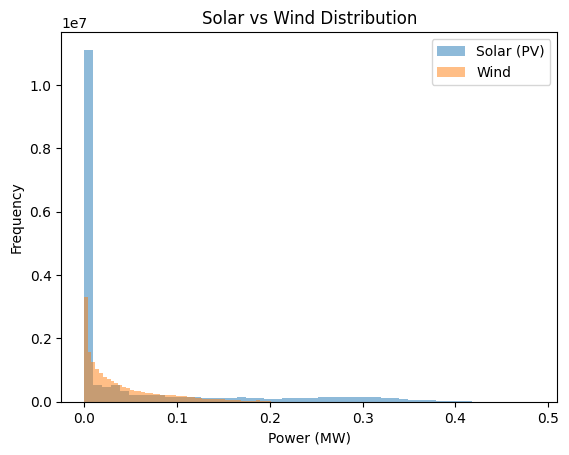

In [11]:
plt.figure()
plt.hist(pv_values, bins=50, alpha=0.5, label="Solar (PV)")
plt.hist(wind_values, bins=50, alpha=0.5, label="Wind")

plt.legend()
plt.title("Solar vs Wind Distribution")
plt.xlabel("Power (MW)")
plt.ylabel("Frequency")

plt.show()